In [1]:
%load_ext autoreload
%autoreload 2

# Task Execution Flow Visualizer

This notebook analyzes a task log JSON file and visualizes the problem-solving flow from question to answer with improved formatting and layout.

In [2]:
import json
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from datetime import datetime
from pathlib import Path

In [3]:
# Load the task log
log_path = "../logs/futurex-past-test1/20250920_175522/task_08992972-a560-a5d1-b7ff-98c52e052872_attempt_1.json"

with open(log_path, 'r') as f:
    task_data = json.load(f)

print(f"Task ID: {task_data['task_id']}")
print(f"Status: {task_data['status']}")
print(f"Final Answer: {task_data['final_boxed_answer']}")

Task ID: 08992972-a560-a5d1-b7ff-98c52e052872
Status: completed
Final Answer: A


In [4]:
from visualiser import extract_question_text, extract_main_agent_reasoning, extract_sub_agent_results, build_execution_flow

# Extract the execution flow
execution_flow = build_execution_flow(task_data)

print("Execution Flow:")
for i, node in enumerate(execution_flow):
    print(f"{i+1}. {node['label']}: {node['content'][:50]}...")

Execution Flow:
1. QUESTION: Benfica vs. Nice (around 2025-08-13T03:00:00Z). 
A...
2. TOOL CALL: execute_subtask: Collect recent match statistics, head-to-head data...
3. SUB-AGENT: FAILED: File not found...
4. TOOL CALL: execute_subtask: Search for publicly available match statistics, he...
5. SUB-AGENT: FAILED: No internet access...
6. SUB-AGENT: FAILED: Task failed...
7. FINAL ANSWER: A...


In [5]:
execution_flow

[{'id': 'question',
  'type': 'QUESTION',
  'label': 'QUESTION',
  'content': 'Benfica vs. Nice (around 2025-08-13T03:00:00Z). \nA.  the outcome be Benfica\nB.  the outcome be Tie\nC',
  'node_color': '#E8F4FD'},
 {'id': 'tool_1',
  'type': 'TOOL_CALL',
  'label': 'TOOL CALL: execute_subtask',
  'content': 'Collect recent match statistics, head-to-head data, and expert predictions for B...',
  'node_color': '#FFF2CC'},
 {'id': 'result_2',
  'type': 'SUB_AGENT_RESULT',
  'label': 'SUB-AGENT: FAILED',
  'content': 'File not found',
  'node_color': '#FFE6E6'},
 {'id': 'tool_3',
  'type': 'TOOL_CALL',
  'label': 'TOOL CALL: execute_subtask',
  'content': 'Search for publicly available match statistics, head-to-head records, and expert...',
  'node_color': '#FFF2CC'},
 {'id': 'result_4',
  'type': 'SUB_AGENT_RESULT',
  'label': 'SUB-AGENT: FAILED',
  'content': 'No internet access',
  'node_color': '#FFE6E6'},
 {'id': 'result_6',
  'type': 'SUB_AGENT_RESULT',
  'label': 'SUB-AGENT: FAILED',

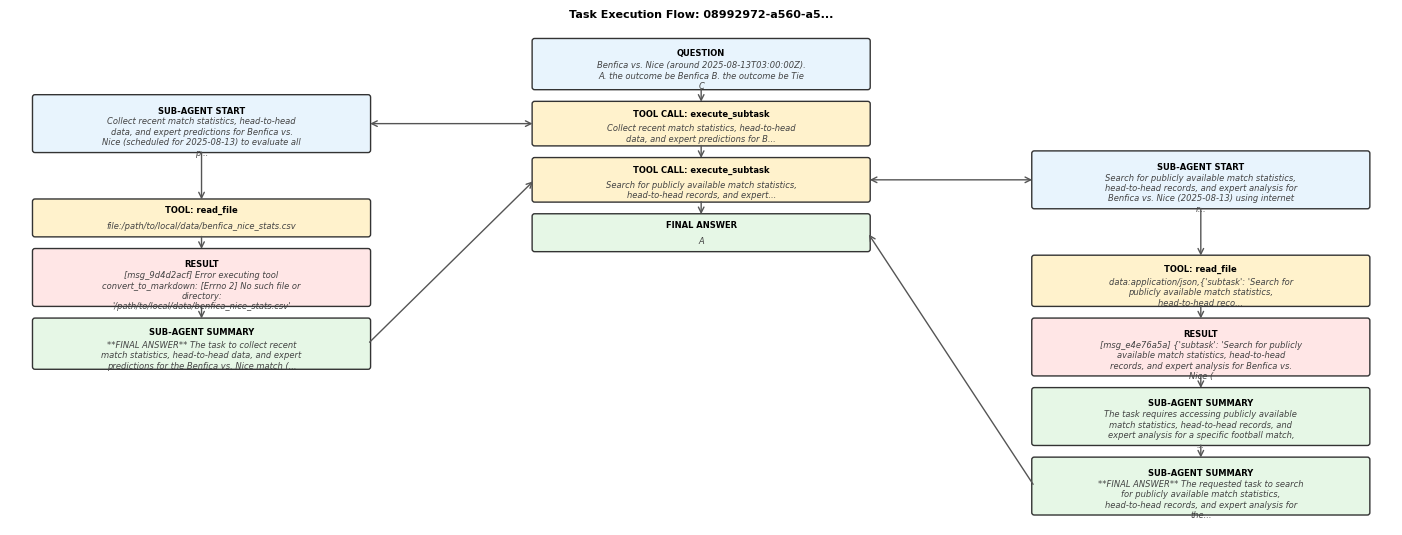

In [10]:
from visualiser import build_execution_flow_dag, create_graph_from_dag, visualize_execution_graph_scaled

dag = build_execution_flow_dag(task_data)
G = create_graph_from_dag(dag)
visualize_execution_graph_scaled(G, scale=0.5, task_data=task_data)

In [7]:
# Analysis summary
print("\n" + "="*60)
print("EXECUTION FLOW ANALYSIS")
print("="*60)

print(f"\n📋 TASK: {extract_question_text(task_data)}")
print(f"\n✅ FINAL ANSWER: {task_data['final_boxed_answer']}")

print(f"\n⏱️  DURATION: {(datetime.fromisoformat(task_data['end_time']) - datetime.fromisoformat(task_data['start_time'])).total_seconds():.1f} seconds")

print(f"\n💰 COST: ${task_data['cost_measurement']['cost_dollars']:.6f}")

# Count events
tool_calls = len([e for e in execution_flow if e['type'] == 'TOOL_CALL'])
failures = len([e for e in execution_flow if e['type'] == 'SUB_AGENT_RESULT'])

print(f"\n🔧 TOOL CALLS: {tool_calls}")
print(f"❌ FAILURES: {failures}")

print(f"\n📊 PROBLEM-SOLVING APPROACH:")
for i, event in enumerate(execution_flow[1:-1], 1):  # Skip question and answer
    if event['type'] == 'TOOL_CALL':
        print(f"  {i}. Attempted: {event['content'][:60]}...")
    elif event['type'] == 'SUB_AGENT_RESULT':
        print(f"     → Result: {event['content']}")

print(f"\n🎯 CONCLUSION: Task attempted multiple approaches but failed due to data access limitations.")


EXECUTION FLOW ANALYSIS

📋 TASK: Benfica vs. Nice (around 2025-08-13T03:00:00Z). 
A.  the outcome be Benfica
B.  the outcome be Tie
C

✅ FINAL ANSWER: A

⏱️  DURATION: 230.1 seconds

💰 COST: $0.003446

🔧 TOOL CALLS: 2
❌ FAILURES: 3

📊 PROBLEM-SOLVING APPROACH:
  1. Attempted: Collect recent match statistics, head-to-head data, and expe...
     → Result: File not found
  3. Attempted: Search for publicly available match statistics, head-to-head...
     → Result: No internet access
     → Result: Task failed

🎯 CONCLUSION: Task attempted multiple approaches but failed due to data access limitations.
